### Problem Definition
- **Business goal:** Build a model that predicts the risk of loan default. The goal is to reduce bad loans by lowering False Negatives, while also avoiding unnecessary rejections by lowering False Positives. The predictions will guide loan amount, tenor, and payment schedule so that customers are motivated to repay in full.
- **ML type:** Supervised learning, binary classification (0 = repaid on time, 1 = default).
- **Success metrics:**
    - **Model:** ROC-AUC, Recall, PR-AUC, F1-Score, Gini Coefficient.
    - **Business:** Lower NPL ratio, higher approval rate, and effective personalization of loan structure by risk segment.

### Data Collection
1. application_train.csv: Main application data (contains the TARGET label)
2. bureau.csv and bureau_balance.csv: Credit history from other institutions
3. previous_application.csv: Previous applications to Home Credit
4. POS_CASH_balance.csv: POS and cash loan installment history at Home Credit
5. credit_card_balance.csv: Credit card history at Home Credit
6. installments_payments.csv: Payment details for each installment

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Global settings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [2]:
# Map each dataset name to its CSV file
files = {
    'app_train': 'application_train.csv',
    'bureau': 'bureau.csv',
    'bureau_bal': 'bureau_balance.csv',
    'prev_app': 'previous_application.csv',
    'pos_cash': 'POS_CASH_balance.csv',
    'credit_card': 'credit_card_balance.csv',
    'installments': 'installments_payments.csv',
}

print('Loading datasets:')

data = {}
for idx, (name, file) in enumerate(files.items(), start=1):
    data[name] = pd.read_csv(file)
    print(f'{idx}. {file} loaded, shape: {data[name].shape}')

print(f'Total datasets loaded: {len(data)}')

Loading datasets:
1. application_train.csv loaded, shape: (307511, 122)
2. bureau.csv loaded, shape: (1716428, 17)
3. bureau_balance.csv loaded, shape: (27299925, 3)
4. previous_application.csv loaded, shape: (1670214, 37)
5. POS_CASH_balance.csv loaded, shape: (10001358, 8)
6. credit_card_balance.csv loaded, shape: (3840312, 23)
7. installments_payments.csv loaded, shape: (13605401, 8)
Total datasets loaded: 7


In [3]:
print('Overview of each dataset')

for name, df in data.items():
    print(f'Dataset: {name.upper()}')
    print(f'Shape: {df.shape}')

    print('First 5 rows:')
    display(df.head())

    print('Column information:')
    df.info()

Overview of each dataset
Dataset: APP_TRAIN
Shape: (307511, 122)
First 5 rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Column information:
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB
Dataset: BUREAU
Shape: (1716428, 17)
First 5 rows:


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


Column information:
<class 'pandas.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           str    
 3   CREDIT_CURRENCY         str    
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             str    
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), str(3)
memory usage: 222.6 MB
Dataset: BUREAU_BAL
Shape: (27299925, 3)
First 5 rows:


...

Column information:
<class 'pandas.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   str    
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), str(1)
memory usage: 610.4 MB
Dataset: CREDIT_CARD
Shape: (3840312, 23)
First 5 rows:


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0
3,1389973,337855,-4,236572.110,225000,2250.0,2250.0,0.0,0.0,11795.760,...,233048.970,233048.970,1.0,1,0.0,0.0,10.0,Active,0,0
4,1891521,126868,-1,453919.455,450000,0.0,11547.0,0.0,11547.0,22924.890,...,453919.455,453919.455,0.0,1,0.0,1.0,101.0,Active,0,0


Column information:
<class 'pandas.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  CNT_INSTALME

,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


Column information:
<class 'pandas.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


In [4]:
print('Descriptive statistics of each dataset')

for name, df in data.items():
    print(f'Dataset: {name.upper()}')
    display(df.describe().T)

Descriptive statistics of each dataset
Dataset: APP_TRAIN


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


Dataset: BUREAU


,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,1716428.0,2.782149e+05,1.029386e+05,100001.000,188866.75,278055.0,367426.00,4.562550e+05
SK_ID_BUREAU,1716428.0,5.924434e+06,5.322657e+05,5000000.000,5463953.75,5926303.5,6385681.25,6.843457e+06
DAYS_CREDIT,1716428.0,-1.142108e+03,7.951649e+02,-2922.000,-1666.00,-987.0,-474.00,0.000000e+00
CREDIT_DAY_OVERDUE,1716428.0,8.181666e-01,3.654443e+01,0.000,0.00,0.0,0.00,2.792000e+03
DAYS_CREDIT_ENDDATE,1610875.0,5.105174e+02,4.994220e+03,-42060.000,-1138.00,-330.0,474.00,3.119900e+04
DAYS_ENDDATE_FACT,1082775.0,-1.017437e+03,7.140106e+02,-42023.000,-1489.00,-897.0,-425.00,0.000000e+00
AMT_CREDIT_MAX_OVERDUE,591940.0,3.825418e+03,2.060316e+05,0.000,0.00,0.0,0.00,1.159872e+08
CNT_CREDIT_PROLONG,1716428.0,6.410406e-03,9.622391e-02,0.000,0.00,0.0,0.00,9.000000e+00
AMT_CREDIT_SUM,1716415.0,3.549946e+05,1.149811e+06,0.000,51300.00,125518.5,315000.00,5.850000e+08
AMT_CREDIT_SUM_DEBT,1458759.0,1.370851e+05,6.774011e+05,-4705600.320,0.00,0.0,40153.50,1.701000e+08


Dataset: BUREAU_BAL


...

,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,10001358.0,1.903217e+06,535846.530722,1000001.0,1434405.0,1896565.0,2368963.0,2843499.0
SK_ID_CURR,10001358.0,2.784039e+05,102763.745090,100001.0,189550.0,278654.0,367429.0,456255.0
MONTHS_BALANCE,10001358.0,-3.501259e+01,26.066570,-96.0,-54.0,-28.0,-13.0,-1.0
CNT_INSTALMENT,9975287.0,1.708965e+01,11.995056,1.0,10.0,12.0,24.0,92.0
CNT_INSTALMENT_FUTURE,9975271.0,1.048384e+01,11.109058,0.0,3.0,7.0,14.0,85.0
SK_DPD,10001358.0,1.160693e+01,132.714043,0.0,0.0,0.0,0.0,4231.0
SK_DPD_DEF,10001358.0,6.544684e-01,32.762491,0.0,0.0,0.0,0.0,3595.0


Dataset: CREDIT_CARD


,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,3840312.0,1.904504e+06,536469.470563,1000018.000,1434385.00,1897122.0,2.369328e+06,2843496.000
SK_ID_CURR,3840312.0,2.783242e+05,102704.475133,100006.000,189517.00,278396.0,3.675800e+05,456250.000
MONTHS_BALANCE,3840312.0,-3.452192e+01,26.667751,-96.000,-55.00,-28.0,-1.100000e+01,-1.000
AMT_BALANCE,3840312.0,5.830016e+04,106307.031024,-420250.185,0.00,0.0,8.904669e+04,1505902.185
AMT_CREDIT_LIMIT_ACTUAL,3840312.0,1.538080e+05,165145.699525,0.000,45000.00,112500.0,1.800000e+05,1350000.000
AMT_DRAWINGS_ATM_CURRENT,3090496.0,5.961325e+03,28225.688578,-6827.310,0.00,0.0,0.000000e+00,2115000.000
AMT_DRAWINGS_CURRENT,3840312.0,7.433388e+03,33846.077333,-6211.620,0.00,0.0,0.000000e+00,2287098.315
AMT_DRAWINGS_OTHER_CURRENT,3090496.0,2.881696e+02,8201.989345,0.000,0.00,0.0,0.000000e+00,1529847.000
AMT_DRAWINGS_POS_CURRENT,3090496.0,2.968805e+03,20796.887047,0.000,0.00,0.0,0.000000e+00,2239274.160
AMT_INST_MIN_REGULARITY,3535076.0,3.540204e+03,5600.154122,0.000,0.00,0.0,6.633911e+03,202882.005


Dataset: INSTALLMENTS


,count,mean,std,min,25%,50%,75%,max
SK_ID_PREV,13605401.0,1.903365e+06,536202.905546,1000001.0,1434191.000,1896520.000,2369094.000,2843499.000
SK_ID_CURR,13605401.0,2.784449e+05,102718.310411,100001.0,189639.000,278685.000,367530.000,456255.000
NUM_INSTALMENT_VERSION,13605401.0,8.566373e-01,1.035216,0.0,0.000,1.000,1.000,178.000
NUM_INSTALMENT_NUMBER,13605401.0,1.887090e+01,26.664067,1.0,4.000,8.000,19.000,277.000
DAYS_INSTALMENT,13605401.0,-1.042270e+03,800.946284,-2922.0,-1654.000,-818.000,-361.000,-1.000
DAYS_ENTRY_PAYMENT,13602496.0,-1.051114e+03,800.585883,-4921.0,-1662.000,-827.000,-370.000,-1.000
AMT_INSTALMENT,13605401.0,1.705091e+04,50570.254429,0.0,4226.085,8884.080,16710.210,3771487.845
AMT_PAYMENT,13602496.0,1.723822e+04,54735.783981,0.0,3398.265,8125.515,16108.425,3771487.845


### Data Cleaning

In [5]:
# Work on a copy of the main application data
train = data['app_train'].copy()

# Count and rank missing values per column
missing = pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing Pct': train.isnull().mean() * 100,
})
missing_summary = (
    missing[missing['Missing Count'] > 0]
    .sort_values(by='Missing Pct', ascending=False)
)

print(f'Columns with missing values: {len(missing_summary)}')
print('Top 25 columns by missing percentage:')
display(missing_summary.head(25))

Columns with missing values: 67
Top 25 columns by missing percentage:


,Missing Count,Missing Pct
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_AVG,214865,69.872297
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


In [6]:
# Drop columns with more than 60% missing values
MISSING_THRESHOLD = 60
cols_to_drop = missing_summary[missing_summary['Missing Pct'] > MISSING_THRESHOLD].index
train = train.drop(columns=cols_to_drop)

print(f'Columns dropped (more than {MISSING_THRESHOLD}% missing): {len(cols_to_drop)}')
print(f'Shape after dropping columns: {train.shape}')

Columns dropped (more than 60% missing): 17
Shape after dropping columns: (307511, 105)


In [7]:
# Check for duplicate rows
print(f'Duplicate rows found: {train.duplicated().sum()}')

Duplicate rows found: 0


In [8]:
# Remove rows with the invalid gender code 'XNA'
xna_count = (train['CODE_GENDER'] == 'XNA').sum()
train = train[train['CODE_GENDER'] != 'XNA']

# Convert day-based columns to years, replace the placeholder 365243 with NaN,
# and cap the number of children at 5
train = train.assign(
    AGE=train['DAYS_BIRTH'].abs() / 365,
    YEARS_EMPLOYED=train['DAYS_EMPLOYED'].replace(365243, np.nan).abs() / 365,
    CNT_CHILDREN=np.minimum(train['CNT_CHILDREN'], 5),
).drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'])

print(f'Rows removed with gender code XNA: {xna_count}')
print('New columns created: AGE and YEARS_EMPLOYED (in years).')
print('CNT_CHILDREN capped at 5.')
print(f'Shape after handling anomalies: {train.shape}')

Rows removed with gender code XNA: 4
New columns created: AGE and YEARS_EMPLOYED (in years).
CNT_CHILDREN capped at 5.
Shape after handling anomalies: (307507, 105)


In [9]:
# Select numeric columns, excluding the target and the ID
excluded_cols = ['TARGET', 'SK_ID_CURR']
numeric_cols = [
    col for col in train.select_dtypes(include=np.number).columns
    if col not in excluded_cols
]

# Binary (0/1) columns are not checked for outliers
binary_cols = [col for col in numeric_cols if train[col].dropna().isin([0, 1]).all()]
outlier_cols = [col for col in numeric_cols if col not in binary_cols]

# Calculate IQR bounds for each column
Q1 = train[outlier_cols].quantile(0.25)
Q3 = train[outlier_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers per column
is_outlier = (train[outlier_cols] < lower_bound) | (train[outlier_cols] > upper_bound)
outliers = is_outlier.sum()

outlier_summary = pd.DataFrame({
    'Total Outliers': outliers,
    'Percentage (%)': (outliers / len(train) * 100).round(2),
    'Skewness': train[outlier_cols].skew().round(2),
})

print(f'Columns checked for outliers: {len(outlier_cols)}')
print('Top 50 columns by number of outliers:')
display(outlier_summary.sort_values('Total Outliers', ascending=False).head(50))

Columns checked for outliers: 56
Top 50 columns by number of outliers:


,Total Outliers,Percentage (%),Skewness
REGION_RATING_CLIENT,80526,26.19,0.09
REGION_RATING_CLIENT_W_CITY,78026,25.37,0.06
AMT_REQ_CREDIT_BUREAU_QRT,50574,16.45,134.37
AMT_REQ_CREDIT_BUREAU_MON,43758,14.23,7.81
DEF_30_CNT_SOCIAL_CIRCLE,35164,11.44,5.18
DEF_60_CNT_SOCIAL_CIRCLE,25767,8.38,5.28
OBS_30_CNT_SOCIAL_CIRCLE,19969,6.49,12.14
OBS_60_CNT_SOCIAL_CIRCLE,19562,6.36,12.07
NONLIVINGAREA_MODE,18817,6.12,6.52
NONLIVINGAREA_MEDI,17254,5.61,6.51


In [10]:
# Cap outliers at the IQR bounds
train[outlier_cols] = train[outlier_cols].clip(lower=lower_bound, upper=upper_bound, axis=1)

# Verify that no outliers remain
is_outlier_after = (train[outlier_cols] < lower_bound) | (train[outlier_cols] > upper_bound)

print(f'Total outliers after capping: {is_outlier_after.sum().sum()}')

Total outliers after capping: 0


### Data Exploration

Target distribution:
TARGET
0    282682
1     24825
Name: count, dtype: int64


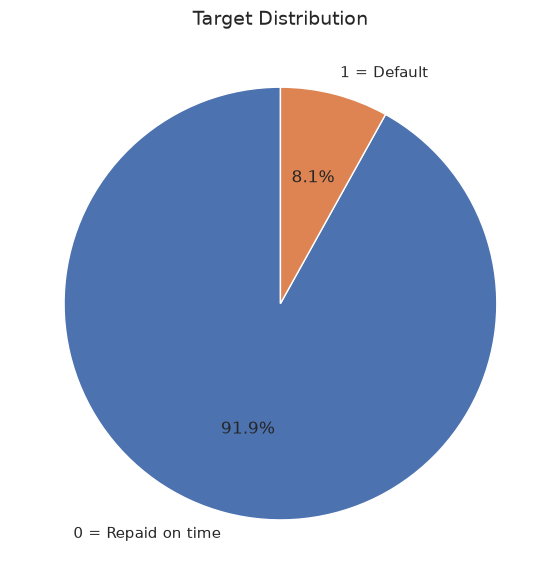

In [11]:
# Pie chart of the target classes
counts = train['TARGET'].value_counts().sort_index()
labels = ['0 = Repaid on time', '1 = Default']

print('Target distribution:')
print(counts)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Target Distribution', fontsize=14)
plt.tight_layout()
plt.show()

Distribution of key numeric features:


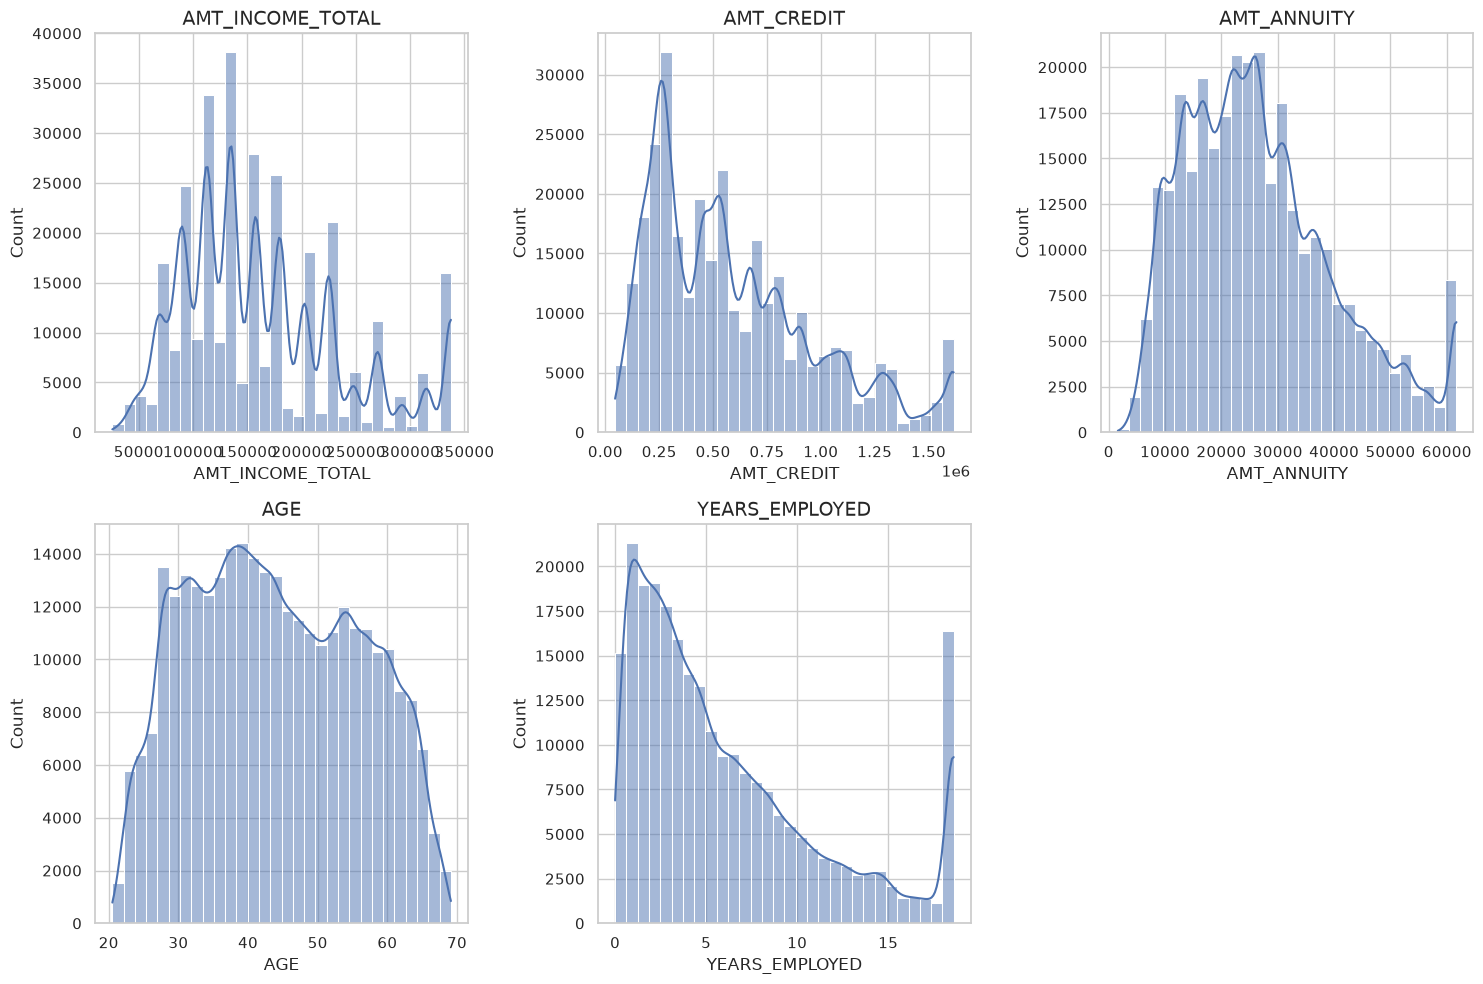

In [12]:
# Histograms of key numeric features
hist_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AGE', 'YEARS_EMPLOYED']

print('Distribution of key numeric features:')

plt.figure(figsize=(15, 10))
for i, col in enumerate(hist_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(train[col], bins=30, kde=True)
    plt.title(col, fontsize=14)
plt.tight_layout()
plt.show()

Distribution of key categorical features:
 


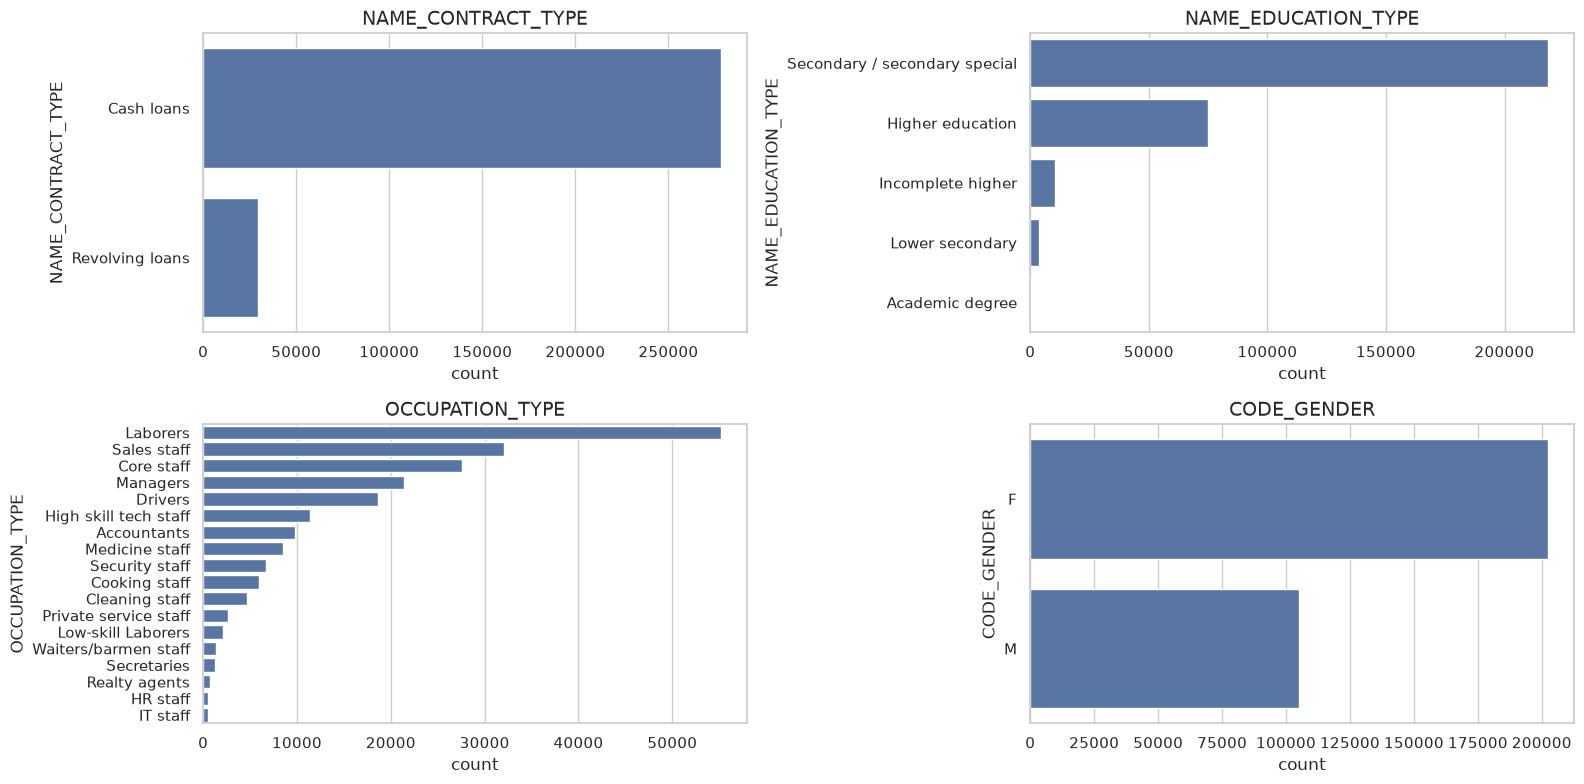

In [13]:
# Count plots of key categorical features
count_plot_cols = ['NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE', 'OCCUPATION_TYPE', 'CODE_GENDER']

print('Distribution of key categorical features:')
print(' ')

plt.figure(figsize=(16, 8))
for i, col in enumerate(count_plot_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(data=train, y=col, order=train[col].value_counts().index)
    plt.title(col, fontsize=14)
plt.tight_layout()
plt.show()

Distribution of key categorical features:


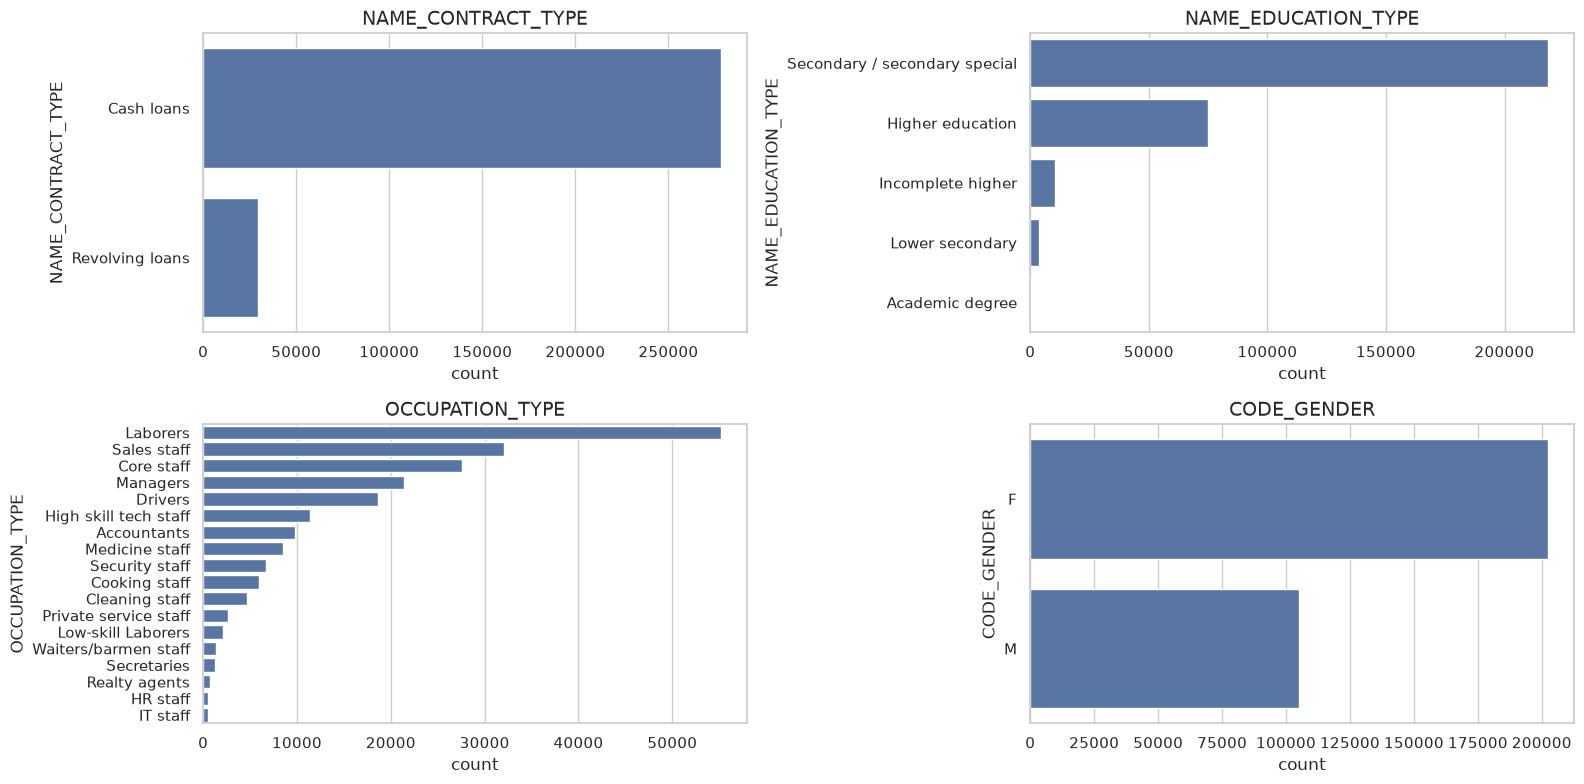

In [14]:
# Count plots of key categorical features
count_plot_cols = ['NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE', 'OCCUPATION_TYPE', 'CODE_GENDER']

print('Distribution of key categorical features:')

plt.figure(figsize=(16, 8))
for i, col in enumerate(count_plot_cols):
    plt.subplot(2, 2, i + 1)
    sns.countplot(data=train, y=col, order=train[col].value_counts().index)
    plt.title(col, fontsize=14)
plt.tight_layout()
plt.show()

Default rate by category:
 


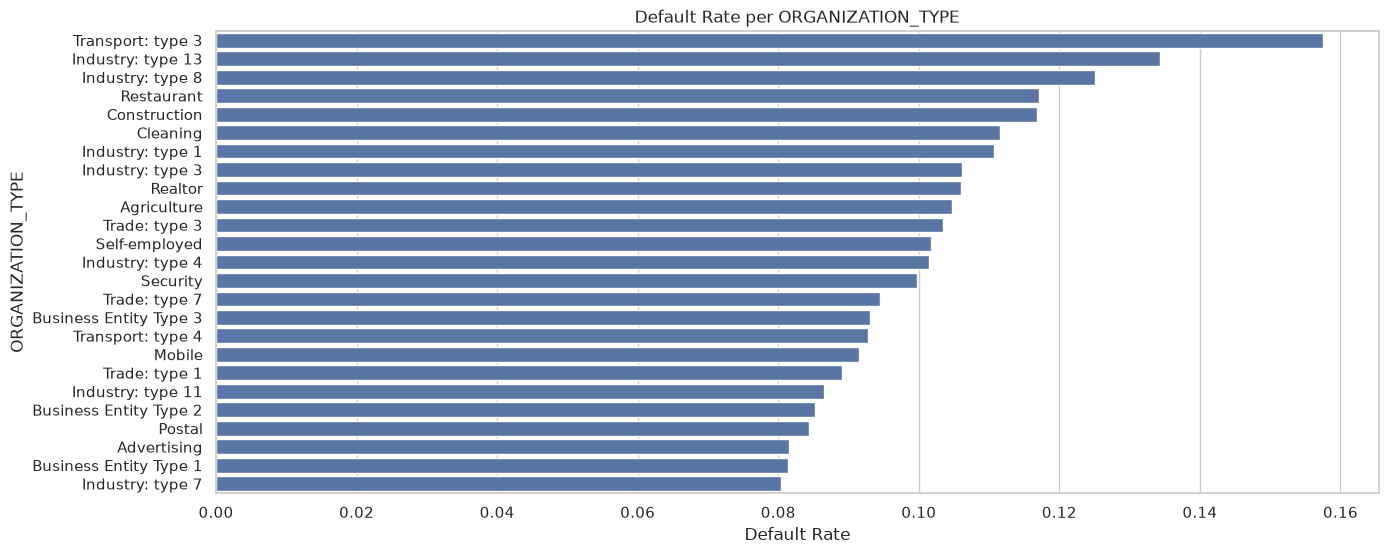

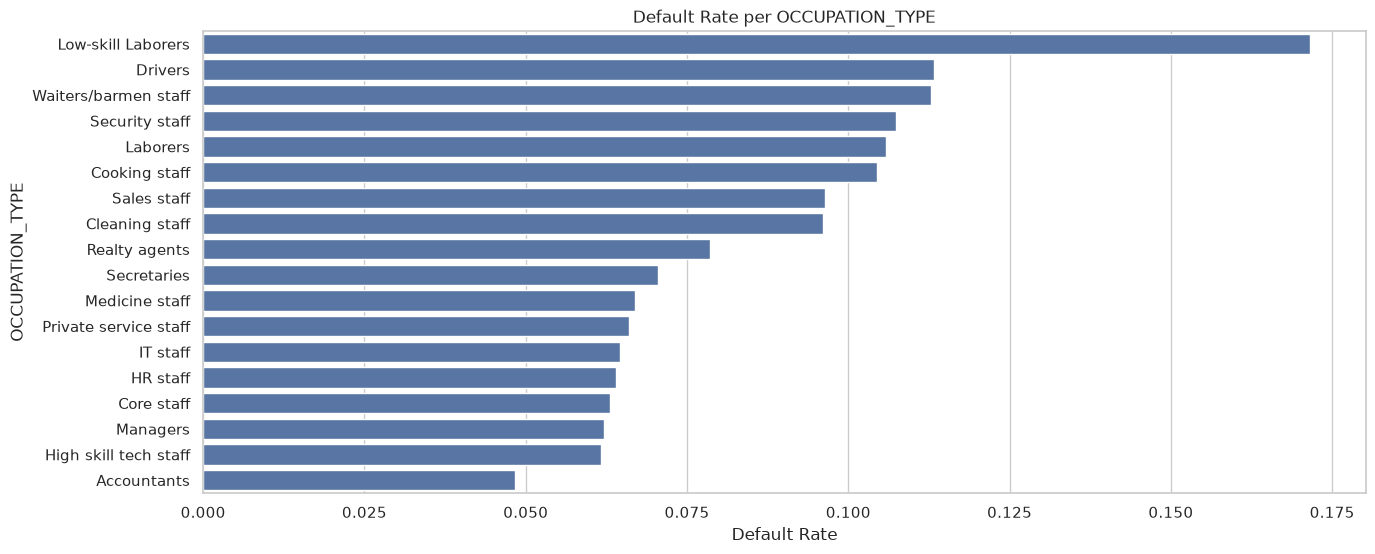

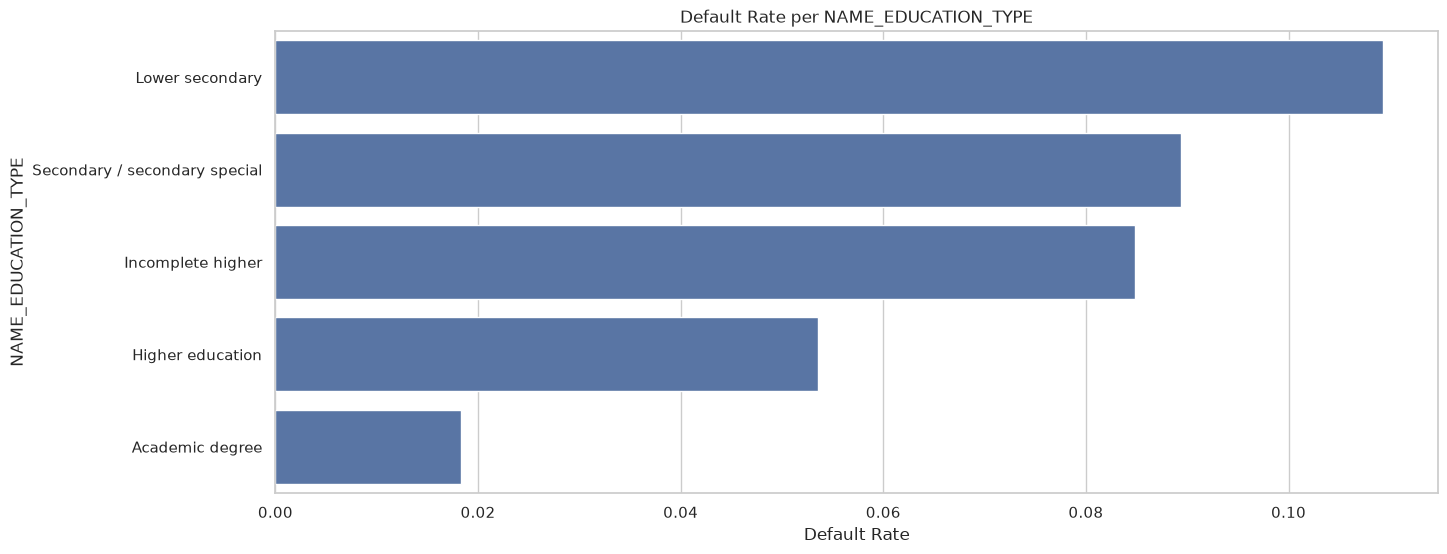

In [15]:
# Default rate per category (top 25 categories)
default_rate_cols = ['ORGANIZATION_TYPE', 'OCCUPATION_TYPE', 'NAME_EDUCATION_TYPE']

print('Default rate by category:')
print(' ')

for col in default_rate_cols:
    default_rate = train.groupby(col)['TARGET'].mean().sort_values(ascending=False).head(25)

    plt.figure(figsize=(15, 6))
    sns.barplot(x=default_rate.values, y=default_rate.index)
    plt.title(f'Default Rate per {col}')
    plt.xlabel('Default Rate')
    plt.show()

Credit amount and income compared with the target:
 


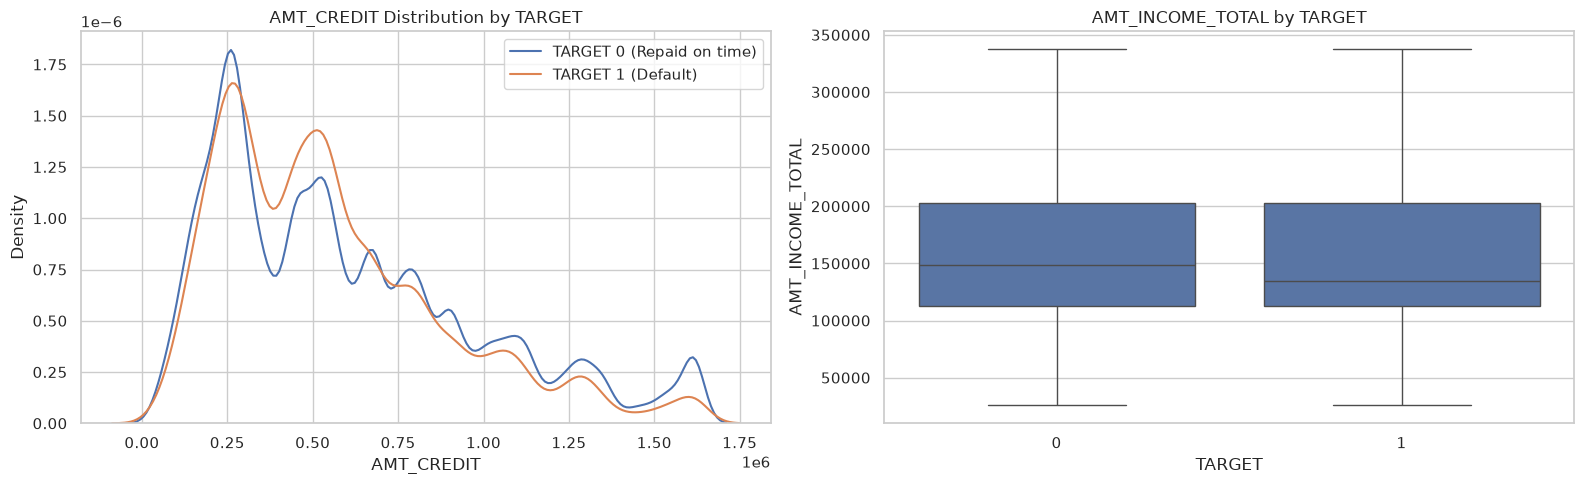

In [16]:
# Compare credit amount and income between repaid and default customers
print('Credit amount and income compared with the target:')
print(' ')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.kdeplot(train.loc[train['TARGET'] == 0, 'AMT_CREDIT'], label='TARGET 0 (Repaid on time)', ax=axes[0])
sns.kdeplot(train.loc[train['TARGET'] == 1, 'AMT_CREDIT'], label='TARGET 1 (Default)', ax=axes[0])
axes[0].set_title('AMT_CREDIT Distribution by TARGET')
axes[0].legend()

sns.boxplot(data=train, x='TARGET', y='AMT_INCOME_TOTAL', ax=axes[1])
axes[1].set_title('AMT_INCOME_TOTAL by TARGET')

plt.tight_layout()
plt.show()

Correlation heatmap of the top 25 numeric features:
 


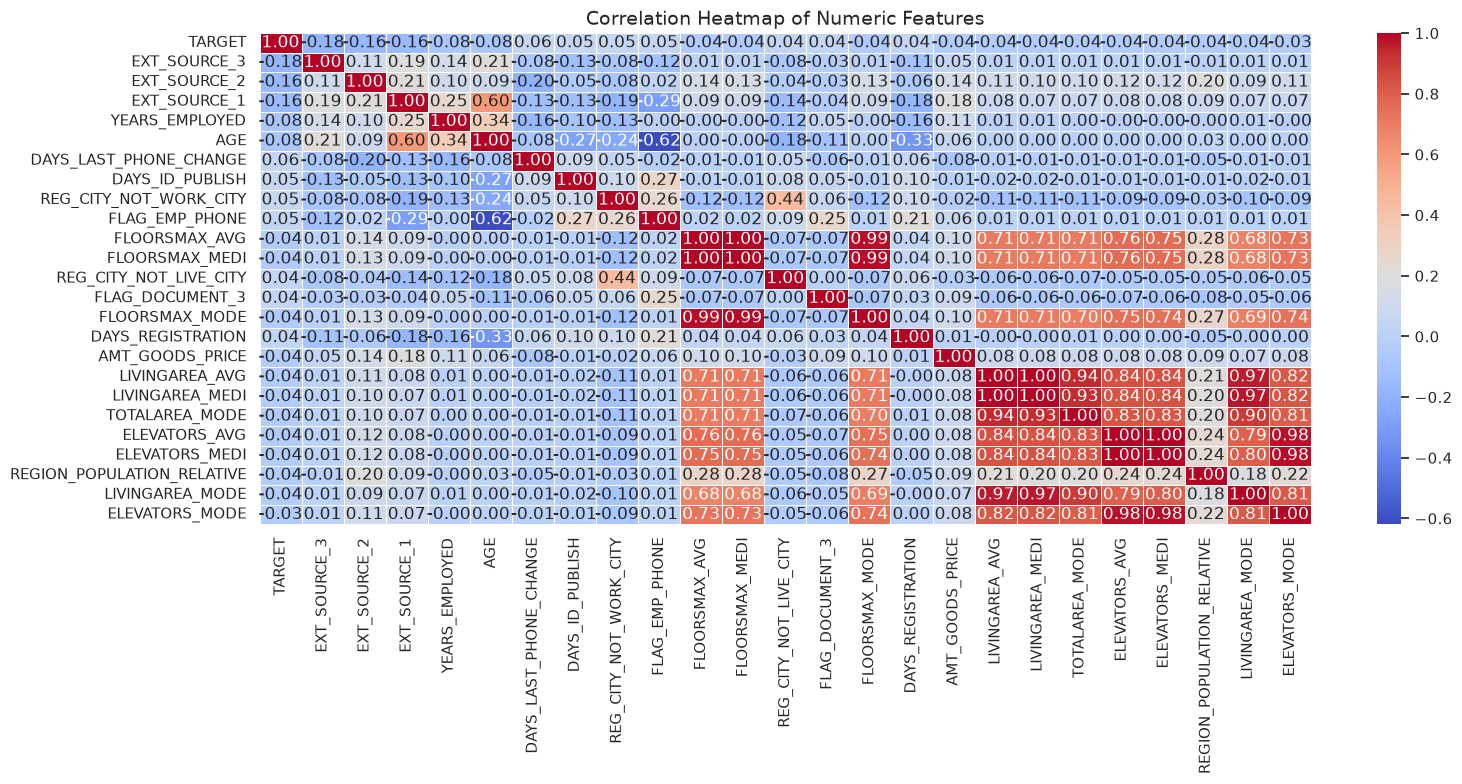

In [17]:
# Correlation of the 25 numeric features most related to the target
numeric_df = train.select_dtypes(include=[np.number])

top_features = (
    numeric_df.corr()['TARGET'].abs().sort_values(ascending=False).head(25).index
)
corr_matrix = numeric_df[top_features].corr()

print('Correlation heatmap of the top 25 numeric features:')
print(' ')

plt.figure(figsize=(16, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# Find highly correlated features (upper triangle only, to avoid counting pairs twice)
CORR_THRESHOLD = 0.95
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

redundant_cols = [
    col for col in upper_tri.columns
    if (upper_tri[col] > CORR_THRESHOLD).any() and col != 'TARGET'
]

print(f'Redundant features found (correlation above {CORR_THRESHOLD}): {len(redundant_cols)}')
print(f'Features to drop: {redundant_cols}')

Redundant features found (correlation above 0.95): 6
Features to drop: ['FLOORSMAX_MEDI', 'FLOORSMAX_MODE', 'LIVINGAREA_MEDI', 'ELEVATORS_MEDI', 'LIVINGAREA_MODE', 'ELEVATORS_MODE']


In [19]:
# Drop the redundant features
train = train.drop(columns=redundant_cols)

print(f'Redundant features dropped: {len(redundant_cols)}')
print(f'Shape after dropping: {train.shape}')

Redundant features dropped: 6
Shape after dropping: (307507, 99)


#### Bureau

In [20]:
bureau = data['bureau'].copy()
bureau_bal = data['bureau_bal'].copy()

# Flag months with a payment delay (status 1 to 5), then summarize per bureau credit
bureau_bal['IS_DPD'] = bureau_bal['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)
bb_agg = bureau_bal.groupby('SK_ID_BUREAU').agg(
    BB_MONTHS_MIN=('MONTHS_BALANCE', 'min'),
    BB_DPD_COUNT=('IS_DPD', 'sum'),
    BB_DPD_MEAN=('IS_DPD', 'mean'),
).reset_index()

bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')

# Summarize bureau credits per customer
bureau['CREDIT_ACTIVE_BIN'] = (bureau['CREDIT_ACTIVE'] == 'Active').astype(int)
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_KREDIT_AKTIF=('CREDIT_ACTIVE_BIN', 'sum'),
    BUREAU_OVERDUE_TOTAL=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    BUREAU_DURASI_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_BB_DPD_TOTAL=('BB_DPD_COUNT', 'sum'),
    BUREAU_BB_DPD_MEAN=('BB_DPD_MEAN', 'mean'),
).reset_index()

print(f'Bureau features created. Shape: {bureau_agg.shape}')
display(bureau_agg.head())

Bureau features created. Shape: (305811, 7)


,SK_ID_CURR,BUREAU_KREDIT_AKTIF,BUREAU_OVERDUE_TOTAL,BUREAU_DURASI_MEAN,BUREAU_COUNT,BUREAU_BB_DPD_TOTAL,BUREAU_BB_DPD_MEAN
0,100001,3,0.0,-735.000000,7,1.0,0.007519
1,100002,2,0.0,-874.000000,8,27.0,0.255682
2,100003,1,0.0,-1400.750000,4,0.0,NaN
3,100004,0,0.0,-867.000000,2,0.0,NaN
4,100005,2,0.0,-190.666667,3,0.0,0.000000


#### Previous Application

In [21]:
prev_app = data['prev_app'].copy()

# Flag approved and refused applications
prev_app['IS_APPROVED'] = (prev_app['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)
prev_app['IS_REFUSED'] = (prev_app['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)

# Summarize previous applications per customer
prev_agg = prev_app.groupby('SK_ID_CURR').agg(
    PREV_COUNT=('SK_ID_PREV', 'count'),
    PREV_APPROVED_SUM=('IS_APPROVED', 'sum'),
    PREV_REFUSED_SUM=('IS_REFUSED', 'sum'),
    PREV_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
).reset_index()
prev_agg['PREV_APPROVED_RATIO'] = prev_agg['PREV_APPROVED_SUM'] / prev_agg['PREV_COUNT']

print(f'Previous application features created. Shape: {prev_agg.shape}')
display(prev_agg.head())

Previous application features created. Shape: (338857, 6)


,SK_ID_CURR,PREV_COUNT,PREV_APPROVED_SUM,PREV_REFUSED_SUM,PREV_CREDIT_MEAN,PREV_APPROVED_RATIO
0,100001,1,1,0,23787.00,1.0
1,100002,1,1,0,179055.00,1.0
2,100003,3,3,0,484191.00,1.0
3,100004,1,1,0,20106.00,1.0
4,100005,2,1,0,20076.75,0.5


#### POS CASH Balance

In [22]:
pos_cash = data['pos_cash'].copy()

# Flag active contracts
pos_cash['IS_ACTIVE'] = (pos_cash['NAME_CONTRACT_STATUS'] == 'Active').astype(int)

# Summarize POS and cash loans per customer
pos_agg = pos_cash.groupby('SK_ID_CURR').agg(
    POS_DPD_MEAN=('SK_DPD', 'mean'),
    POS_DPD_MAX=('SK_DPD', 'max'),
    POS_KONTRAK_AKTIF=('IS_ACTIVE', 'sum'),
).reset_index()

print(f'POS cash features created. Shape: {pos_agg.shape}')
display(pos_agg.head())

POS cash features created. Shape: (337252, 4)


,SK_ID_CURR,POS_DPD_MEAN,POS_DPD_MAX,POS_KONTRAK_AKTIF
0,100001,0.777778,7,7
1,100002,0.000000,0,19
2,100003,0.000000,0,26
3,100004,0.000000,0,3
4,100005,0.000000,0,9


#### Credit Card Balance

In [23]:
credit_card = data['credit_card'].copy()

# Replace a zero credit limit with NaN to avoid division by zero (inf values)
credit_card['LIMIT_USE_RATIO'] = (
    credit_card['AMT_BALANCE'] / credit_card['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)
)

# Summarize credit card usage per customer
cc_agg = credit_card.groupby('SK_ID_CURR').agg(
    CC_LIMIT_USE_RATIO_MEAN=('LIMIT_USE_RATIO', 'mean'),
    CC_SALDO_MEAN=('AMT_BALANCE', 'mean'),
).reset_index()

print(f'Credit card features created. Shape: {cc_agg.shape}')
display(cc_agg.head())

Credit card features created. Shape: (103558, 3)


,SK_ID_CURR,CC_LIMIT_USE_RATIO_MEAN,CC_SALDO_MEAN
0,100006,0.000000,0.000000
1,100011,0.302678,54482.111149
2,100013,0.115301,18159.919219
3,100021,0.000000,0.000000
4,100023,0.000000,0.000000


#### Installments Payments

In [24]:
installments = data['installments'].copy()

# Days past due: a negative value means an early payment, so it is set to 0
installments['DPD'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
installments['DPD'] = installments['DPD'].clip(lower=0)

# Flag late payments and underpayments
installments['IS_LATE'] = (installments['DPD'] > 0).astype(int)
installments['IS_LESS_PAY'] = (installments['AMT_PAYMENT'] < installments['AMT_INSTALMENT']).astype(int)

# Summarize payment behavior per customer
inst_agg = installments.groupby('SK_ID_CURR').agg(
    INST_DPD_MEAN=('DPD', 'mean'),
    INST_DPD_MAX=('DPD', 'max'),
    INST_PERSEN_TELAT=('IS_LATE', 'mean'),
    INST_PERSEN_KURANG=('IS_LESS_PAY', 'mean'),
).reset_index()

print(f'Installment features created. Shape: {inst_agg.shape}')
display(inst_agg.head())

Installment features created. Shape: (339587, 5)


,SK_ID_CURR,INST_DPD_MEAN,INST_DPD_MAX,INST_PERSEN_TELAT,INST_PERSEN_KURANG
0,100001,1.571429,11.0,0.142857,0.0
1,100002,0.000000,0.0,0.000000,0.0
2,100003,0.000000,0.0,0.000000,0.0
3,100004,0.000000,0.0,0.000000,0.0
4,100005,0.111111,1.0,0.111111,0.0


#### Merging (Left Join)

In [25]:
# Start from the cleaned application data and add each history table
df_full = train.copy()

agg_tables = {
    'bureau': bureau_agg,
    'prev_app': prev_agg,
    'pos_cash': pos_agg,
    'credit_card': cc_agg,
    'installments': inst_agg,
}

print('Merging history tables into the application data (left join):')

for name, agg_df in agg_tables.items():
    cols_before = df_full.shape[1]
    df_full = df_full.merge(agg_df, on='SK_ID_CURR', how='left')
    print(f'{name:12s} added {df_full.shape[1] - cols_before} columns, shape is now {df_full.shape}')


Merging history tables into the application data (left join):
bureau       added 6 columns, shape is now (307507, 105)
prev_app     added 5 columns, shape is now (307507, 110)
pos_cash     added 3 columns, shape is now (307507, 113)
credit_card  added 2 columns, shape is now (307507, 115)
installments added 4 columns, shape is now (307507, 119)


In [26]:
# Flag whether each customer has history in each table
for name, agg_df in agg_tables.items():
    flag_col = f'HAS_{name.upper()}_HISTORY'
    df_full[flag_col] = df_full['SK_ID_CURR'].isin(agg_df['SK_ID_CURR']).astype(int)

# Each customer must appear only once after merging
assert df_full['SK_ID_CURR'].nunique() == len(df_full), 'SK_ID_CURR is not unique after merging.'

print('History flags created for all tables.')
print(f'Final shape of df_full: {df_full.shape}')

History flags created for all tables.
Final shape of df_full: (307507, 124)


#### Feature Engineering (Application Level)

In [27]:
# Financial ratios (zero denominators are replaced with NaN to avoid inf values)
df_full['CREDIT_INCOME_RATIO'] = df_full['AMT_CREDIT'] / df_full['AMT_INCOME_TOTAL'].replace(0, np.nan)
df_full['ANNUITY_INCOME_RATIO'] = df_full['AMT_ANNUITY'] / df_full['AMT_INCOME_TOTAL'].replace(0, np.nan)
df_full['CREDIT_TERM'] = df_full['AMT_ANNUITY'] / df_full['AMT_CREDIT'].replace(0, np.nan)
df_full['EMPLOYED_RATIO'] = df_full['YEARS_EMPLOYED'] / df_full['AGE']

print('Financial ratio features created:')
print('CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO, CREDIT_TERM, EMPLOYED_RATIO')

Financial ratio features created:
CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO, CREDIT_TERM, EMPLOYED_RATIO


In [28]:
print(f'Shape of df_full: {df_full.shape}')

Shape of df_full: (307507, 128)


In [29]:
print('Last 25 rows of df_full:')
display(df_full.tail(25))

Last 25 rows of df_full:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INST_PERSEN_KURANG,HAS_BUREAU_HISTORY,HAS_PREV_APP_HISTORY,HAS_POS_CASH_HISTORY,HAS_CREDIT_CARD_HISTORY,HAS_INSTALLMENTS_HISTORY,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,EMPLOYED_RATIO
307482,456230,0,Cash loans,F,Y,Y,1.0,292500.0,355536.0,18283.5,...,0.000000,1,1,1,0,1,1.215508,0.062508,0.051425,0.074016
307483,456231,0,Cash loans,M,N,Y,0.0,117000.0,1071909.0,31473.0,...,0.000000,1,1,1,0,1,9.161615,0.269000,0.029362,NaN
307484,456232,0,Cash loans,F,N,N,0.0,157500.0,135000.0,13351.5,...,0.000000,1,1,1,0,1,0.857143,0.084771,0.098900,0.120690
307485,456233,1,Cash loans,F,N,Y,0.0,225000.0,521280.0,23089.5,...,0.000000,1,1,1,1,1,2.316800,0.102620,0.044294,0.017364
307486,456234,0,Cash loans,M,N,Y,0.0,81000.0,135000.0,9148.5,...,0.142857,1,1,1,0,1,1.666667,0.112944,0.067767,0.195260
307487,456235,0,Cash loans,M,Y,Y,2.0,90000.0,1078200.0,31522.5,...,0.000000,1,1,1,1,1,11.980000,0.350250,0.029236,0.177934
307488,456236,0,Cash loans,M,Y,Y,0.0,337500.0,1575000.0,43443.0,...,0.076336,1,1,1,1,1,4.666667,0.128720,0.027583,0.077176
307489,456237,0,Cash loans,F,N,Y,0.0,135000.0,946764.0,37678.5,...,0.029851,1,1,1,1,1,7.013067,0.279100,0.039797,0.131523
307490,456238,0,Cash loans,M,Y,N,1.0,270000.0,479700.0,46858.5,...,0.000000,1,1,1,0,1,1.776667,0.173550,0.097683,0.439430
307491,456239,0,Cash loans,M,Y,N,0.0,180000.0,808650.0,23773.5,...,0.000000,1,1,1,1,1,4.492500,0.132075,0.029399,0.324395


### Preprocessing

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Global settings
TARGET = 'TARGET'
RANDOM_STATE = 42
CARDINALITY_THRESHOLD = 15

# Cross-validation splitter used for all models
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Feature columns (exclude the target and the ID)
feature_cols = [c for c in df_full.columns if c not in [TARGET, 'SK_ID_CURR']]

# Split features by type
cat_cols = df_full[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df_full[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

# Split categorical features by number of unique values
low_card_cats = [c for c in cat_cols if df_full[c].nunique(dropna=True) <= CARDINALITY_THRESHOLD]
high_card_cats = [c for c in cat_cols if df_full[c].nunique(dropna=True) > CARDINALITY_THRESHOLD]

print(f'Numeric columns: {len(num_cols)}')
print(f'Low-cardinality categorical columns (up to {CARDINALITY_THRESHOLD} unique values): {low_card_cats}')
print(f'High-cardinality categorical columns: {high_card_cats}')

Numeric columns: 111
Low-cardinality categorical columns (up to 15 unique values): ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
High-cardinality categorical columns: ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


In [31]:
X = df_full[feature_cols].copy()
y = df_full[TARGET].copy()

# Stratified split keeps the default rate the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f'Train set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')
print(f'Default rate in train set: {y_train.mean():.4f}')
print(f'Default rate in test set: {y_test.mean():.4f}')

Train set shape: (246005, 126)
Test set shape: (61502, 126)
Default rate in train set: 0.0807
Default rate in test set: 0.0807


In [32]:
lr_num_cols = num_cols
lr_cat_cols = low_card_cats

numeric_transformer_lr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer_lr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor_lr = ColumnTransformer(transformers=[
    ('num', numeric_transformer_lr, lr_num_cols),
    ('cat', categorical_transformer_lr, lr_cat_cols),
])

print('Logistic Regression preprocessing is ready.')
print(f'Numeric columns: {len(lr_num_cols)}, categorical columns: {len(lr_cat_cols)}')

Logistic Regression preprocessing is ready.
Numeric columns: 111, categorical columns: 13


In [33]:
# LightGBM handles categorical columns natively, so all of them are kept.
# The test set reuses the categories learned from the train set.
X_train_lgbm = X_train.copy()
X_test_lgbm = X_test.copy()

all_cats_lgbm = low_card_cats + high_card_cats
for c in all_cats_lgbm:
    X_train_lgbm[c] = X_train_lgbm[c].astype('category')
    X_test_lgbm[c] = X_test_lgbm[c].astype(
        pd.CategoricalDtype(categories=X_train_lgbm[c].cat.categories)
    )

print(f'Categorical columns converted for LightGBM: {all_cats_lgbm}')
print(' ')

Categorical columns converted for LightGBM: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
 


### Modeling

In [34]:
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

# Baseline model: Logistic Regression with class balancing
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])

# Cross-validation on the train set
cv_auc_lr = cross_val_score(
    lr_pipeline, X_train, y_train,
    cv=skf, scoring='roc_auc', n_jobs=-1,
)
print(f'Logistic Regression cross-validation AUC: mean {cv_auc_lr.mean():.4f}, std {cv_auc_lr.std():.4f}')

# Fit on the full train set and score on the test set
lr_pipeline.fit(X_train, y_train)
lr_test_auc = roc_auc_score(y_test, lr_pipeline.predict_proba(X_test)[:, 1])
print(f'Logistic Regression test AUC: {lr_test_auc:.4f}')

# Build a coefficient table (numeric features are scaled, so odds ratios are per 1 standard deviation)
ohe_feature_names = (
    lr_pipeline.named_steps['preprocessor']
    .named_transformers_['cat'].named_steps['onehot']
    .get_feature_names_out(lr_cat_cols)
)
all_feature_names = np.concatenate([lr_num_cols, ohe_feature_names])

coefs = lr_pipeline.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coefs,
    'odds_ratio': np.exp(coefs),
}).sort_values('odds_ratio', ascending=False)

print('Top 10 features that increase default risk (odds ratio above 1):')
print(coef_df.head(10))

print('Top 10 features that decrease default risk (odds ratio below 1):')
print(coef_df.tail(10))

Logistic Regression cross-validation AUC: mean 0.7582, std 0.0020
Logistic Regression test AUC: 0.7630
Top 10 features that increase default risk (odds ratio above 1):
                                               feature  coefficient  \
2                                           AMT_CREDIT     0.495643   
137                NAME_EDUCATION_TYPE_Lower secondary     0.335508   
43                                   BASEMENTAREA_MEDI     0.275448   
55                                     FLAG_DOCUMENT_3     0.207894   
3                                          AMT_ANNUITY     0.199688   
27                                      APARTMENTS_AVG     0.197647   
138  NAME_EDUCATION_TYPE_Secondary / secondary special     0.185105   
132                        NAME_INCOME_TYPE_Unemployed     0.177578   
114                                      CODE_GENDER_M     0.158708   
82                                 BUREAU_KREDIT_AKTIF     0.156242   

     odds_ratio  
2      1.641554  
137    1.39865

In [35]:
lgbm_params = {
    'objective': 'binary',
    'metric': 'auc',
    'is_unbalance': True,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'random_state': RANDOM_STATE,
    'verbosity': -1,
}


def train_lgbm(X_tr, y_tr, X_val, y_val):
    """Train LightGBM with early stopping on the given validation set."""
    train_set = lgb.Dataset(X_tr, label=y_tr, categorical_feature=all_cats_lgbm)
    val_set = lgb.Dataset(X_val, label=y_val, categorical_feature=all_cats_lgbm, reference=train_set)
    return lgb.train(
        lgbm_params,
        train_set,
        num_boost_round=1000,
        valid_sets=[val_set],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
    )


# Cross-validation on the train set
cv_auc_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_lgbm, y_train), start=1):
    X_tr, X_val = X_train_lgbm.iloc[train_idx], X_train_lgbm.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    fold_model = train_lgbm(X_tr, y_tr, X_val, y_val)
    val_pred = fold_model.predict(X_val, num_iteration=fold_model.best_iteration)
    fold_auc = roc_auc_score(y_val, val_pred)
    cv_auc_scores.append(fold_auc)

    print(f'LightGBM fold {fold} AUC: {fold_auc:.4f} (best iteration: {fold_model.best_iteration})')

print(f'LightGBM cross-validation AUC: mean {np.mean(cv_auc_scores):.4f}, std {np.std(cv_auc_scores):.4f}')

# Final model: hold out 10% of the train set for early stopping
X_fit_tr, X_fit_val, y_fit_tr, y_fit_val = train_test_split(
    X_train_lgbm, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
final_lgbm = train_lgbm(X_fit_tr, y_fit_tr, X_fit_val, y_fit_val)

# Score the final model on the test set
test_pred = final_lgbm.predict(X_test_lgbm, num_iteration=final_lgbm.best_iteration)
lgbm_test_auc = roc_auc_score(y_test, test_pred)
print(f'LightGBM test AUC: {lgbm_test_auc:.4f}')

# Baseline summary before tuning
baseline_summary = pd.DataFrame({
    'model': ['Logistic Regression', 'LightGBM'],
    'cv_auc_mean': [cv_auc_lr.mean(), np.mean(cv_auc_scores)],
    'cv_auc_std': [cv_auc_lr.std(), np.std(cv_auc_scores)],
    'test_auc': [lr_test_auc, lgbm_test_auc],
})
print('Baseline model summary (before tuning):')
print(baseline_summary)

LightGBM fold 1 AUC: 0.7694 (best iteration: 258)
LightGBM fold 2 AUC: 0.7666 (best iteration: 232)
LightGBM fold 3 AUC: 0.7707 (best iteration: 223)
LightGBM cross-validation AUC: mean 0.7689, std 0.0017
LightGBM test AUC: 0.7747
Baseline model summary (before tuning):
                 model  cv_auc_mean  cv_auc_std  test_auc
0  Logistic Regression     0.758156    0.001991  0.763046
1             LightGBM     0.768896    0.001705  0.774717


### Model Evaluation

In [36]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    recall_score,
    roc_curve,
)

# Predicted default probabilities on the test set
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lgbm_proba = final_lgbm.predict(X_test_lgbm, num_iteration=final_lgbm.best_iteration)

models_proba = {
    'Logistic Regression': lr_proba,
    'LightGBM': lgbm_proba,
}

# Calculate metrics for each model
results = []
for name, proba in models_proba.items():
    roc_auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    pred_05 = (proba >= 0.5).astype(int)

    results.append({
        'model': name,
        'ROC_AUC': roc_auc,
        'PR_AUC': pr_auc,
        'Gini': 2 * roc_auc - 1,
        'Recall@0.5': recall_score(y_test, pred_05),
        'F1@0.5': f1_score(y_test, pred_05),
    })

eval_df = pd.DataFrame(results)

print('Model comparison (Recall and F1 use the default threshold of 0.5):')
print(eval_df.round(4))
print(' ')

Model comparison (Recall and F1 use the default threshold of 0.5):
                 model  ROC_AUC  PR_AUC    Gini  Recall@0.5  F1@0.5
0  Logistic Regression   0.7630  0.2451  0.5261      0.6920  0.2725
1             LightGBM   0.7747  0.2708  0.5494      0.6894  0.2855
 


### Model Evaluation

In [37]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    recall_score,
    roc_curve,
)

# Predicted default probabilities on the test set
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lgbm_proba = final_lgbm.predict(X_test_lgbm, num_iteration=final_lgbm.best_iteration)

models_proba = {
    'Logistic Regression': lr_proba,
    'LightGBM': lgbm_proba,
}

# Calculate metrics for each model
results = []
for name, proba in models_proba.items():
    roc_auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    pred_05 = (proba >= 0.5).astype(int)

    results.append({
        'model': name,
        'ROC_AUC': roc_auc,
        'PR_AUC': pr_auc,
        'Gini': 2 * roc_auc - 1,
        'Recall@0.5': recall_score(y_test, pred_05),
        'F1@0.5': f1_score(y_test, pred_05),
    })

eval_df = pd.DataFrame(results)

print('Model comparison (Recall and F1 use the default threshold of 0.5):')
print(eval_df.round(4))

Model comparison (Recall and F1 use the default threshold of 0.5):
                 model  ROC_AUC  PR_AUC    Gini  Recall@0.5  F1@0.5
0  Logistic Regression   0.7630  0.2451  0.5261      0.6920  0.2725
1             LightGBM   0.7747  0.2708  0.5494      0.6894  0.2855


Curves saved as roc_pr_curve.png


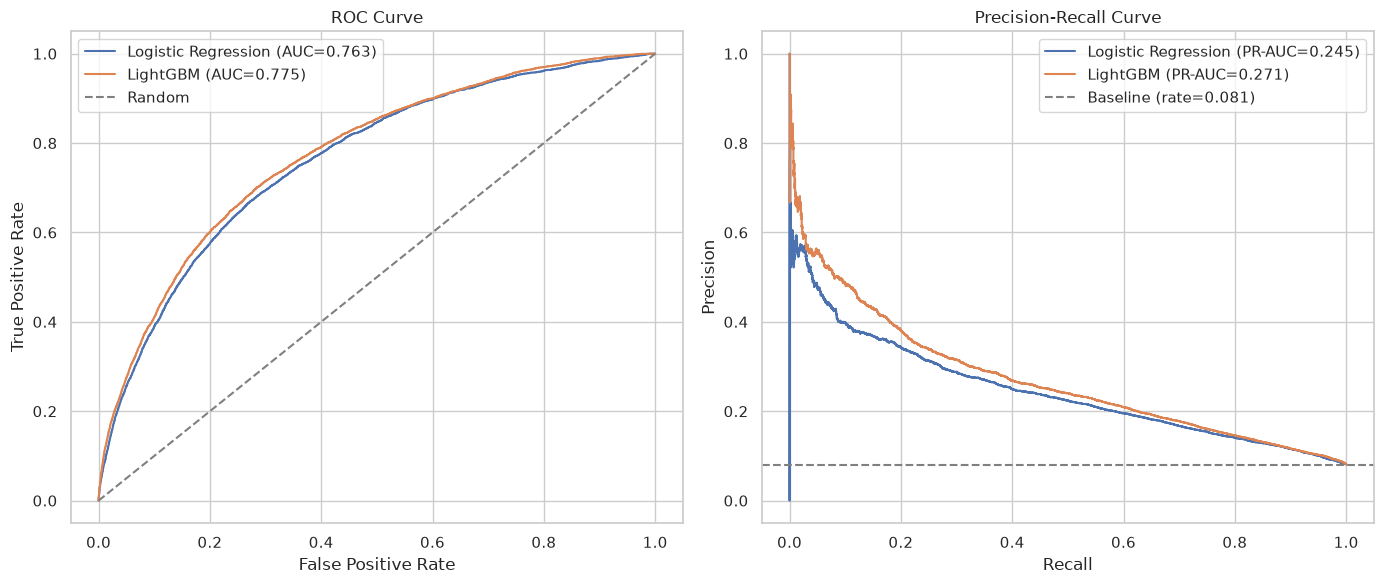

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curve
for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Precision-Recall curve (the baseline is the share of positive cases)
baseline_precision = y_test.mean()
for name, proba in models_proba.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, label=f'{name} (PR-AUC={ap:.3f})')

axes[1].axhline(baseline_precision, linestyle='--', color='gray',
                label=f'Baseline (rate={baseline_precision:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('roc_pr_curve.png', dpi=120)

print('Curves saved as roc_pr_curve.png')

Logistic Regression: best threshold for F1 is 0.66, F1 score is 0.3117
LightGBM: best threshold for F1 is 0.65, F1 score is 0.3253


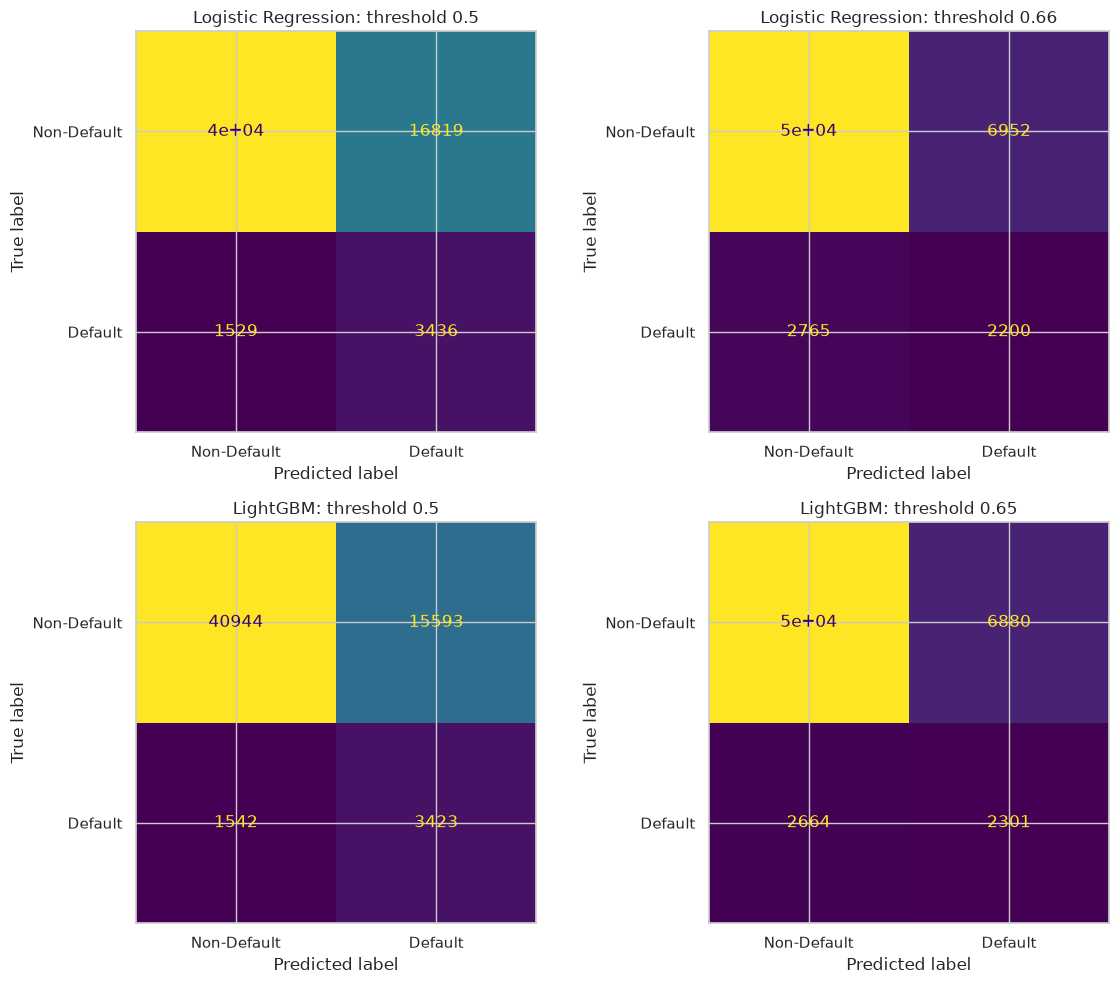

Confusion matrices saved as confusion_matrices.png


In [39]:
def find_best_threshold(y_true, proba, metric='f1'):
    thresholds = np.linspace(0.01, 0.99, 99)
    best_thr, best_score = 0.5, -1

    for thr in thresholds:
        pred = (proba >= thr).astype(int)
        score = f1_score(y_true, pred) if metric == 'f1' else recall_score(y_true, pred)
        if score > best_score:
            best_thr, best_score = thr, score

    return best_thr, best_score

best_thresholds = {}
for name, proba in models_proba.items():
    best_thr, best_f1 = find_best_threshold(y_test, proba, metric='f1')
    best_thresholds[name] = best_thr
    print(f'{name}: best threshold for F1 is {best_thr:.2f}, F1 score is {best_f1:.4f}')


# Confusion matrices: default threshold (0.5) versus best threshold
class_labels = ['Non-Default', 'Default']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, (name, proba) in enumerate(models_proba.items()):
    cm_default = confusion_matrix(y_test, (proba >= 0.5).astype(int))
    ConfusionMatrixDisplay(cm_default, display_labels=class_labels).plot(ax=axes[i, 0], colorbar=False)
    axes[i, 0].set_title(f'{name}: threshold 0.5')

    thr = best_thresholds[name]
    cm_best = confusion_matrix(y_test, (proba >= thr).astype(int))
    ConfusionMatrixDisplay(cm_best, display_labels=class_labels).plot(ax=axes[i, 1], colorbar=False)
    axes[i, 1].set_title(f'{name}: threshold {thr:.2f}')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()

print('Confusion matrices saved as confusion_matrices.png')

Top 20 features by importance (LightGBM, measured by gain):
                     feature  importance_gain  importance_split
38              EXT_SOURCE_3         281547.3               232
37              EXT_SOURCE_2         242183.7               271
35         ORGANIZATION_TYPE         159212.0              1244
36              EXT_SOURCE_1          91510.0               287
124              CREDIT_TERM          76491.2               401
115        INST_PERSEN_TELAT          37521.4               135
96            YEARS_EMPLOYED          34546.9                86
111  CC_LIMIT_USE_RATIO_MEAN          27711.1               126
23           OCCUPATION_TYPE          27101.3               194
95                       AGE          23504.8               149
110        POS_KONTRAK_AKTIF          23122.3               147
11       NAME_EDUCATION_TYPE          20942.3                40
99        BUREAU_DURASI_MEAN          20652.9               120
8            AMT_GOODS_PRICE          17143.

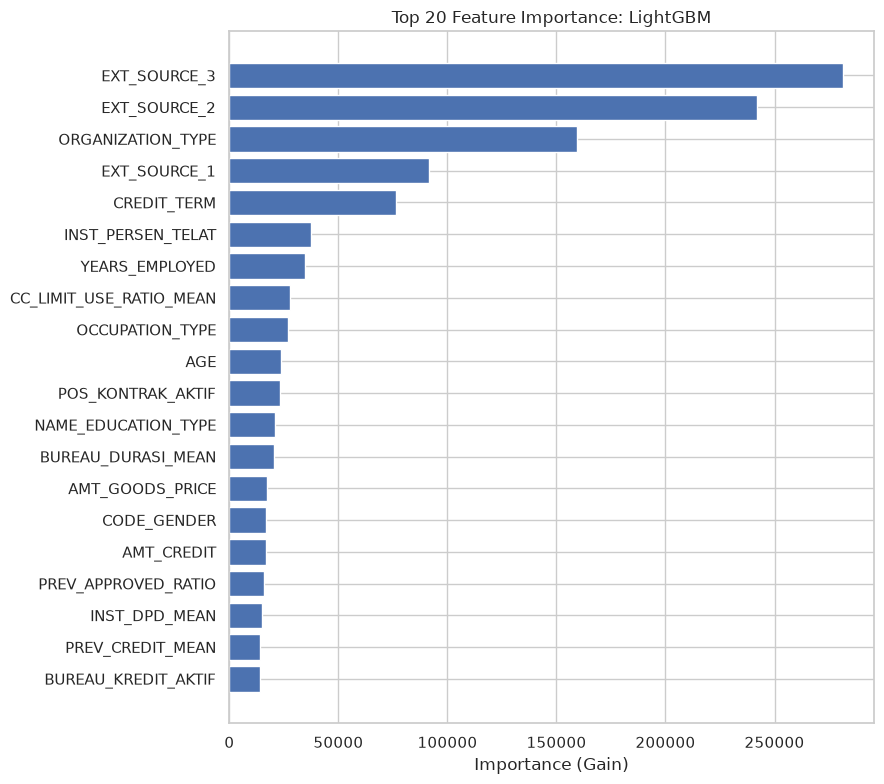

Chart saved as feature_importance_top20.png


In [40]:
# Feature importance from the final LightGBM model
importance_df = pd.DataFrame({
    'feature': final_lgbm.feature_name(),
    'importance_gain': final_lgbm.feature_importance(importance_type='gain'),
    'importance_split': final_lgbm.feature_importance(importance_type='split'),
}).sort_values('importance_gain', ascending=False)

top20 = importance_df.head(20)

print('Top 20 features by importance (LightGBM, measured by gain):')
print(top20.round(1))

plt.figure(figsize=(9, 8))
plt.barh(top20['feature'][::-1], top20['importance_gain'][::-1])
plt.xlabel('Importance (Gain)')
plt.title('Top 20 Feature Importance: LightGBM')
plt.tight_layout()
plt.savefig('feature_importance_top20.png', dpi=120)
plt.show()

print('Chart saved as feature_importance_top20.png')

In [41]:
def business_impact(y_true, proba, threshold, label):
    """Print the business impact of using a given threshold to reject applications."""
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    total_bad = tp + fn          # customers who actually default
    total_good = tn + fp         # customers who actually repay
    total_flagged = tp + fp      # applications rejected by the model

    recall = tp / total_bad
    fp_rate = fp / total_good
    precision = tp / total_flagged if total_flagged > 0 else 0

    print(f'Threshold {threshold:.2f} ({label})')
    print(f'Bad loans caught (recall): {tp} of {total_bad} ({recall:.1%})')
    print(f'Bad loans missed (false negatives): {fn} of {total_bad} ({fn / total_bad:.1%})')
    print(f'Good customers wrongly rejected (false positives): {fp} of {total_good} ({fp_rate:.1%})')
    print(f'Precision among rejected applications: {precision:.1%}')
    print(f'Total applications rejected: {total_flagged} ({total_flagged / len(y_true):.1%} of all applications)')

    return {'recall': recall, 'fp_rate': fp_rate, 'precision': precision}


print('LightGBM business impact at different thresholds:')

thresholds_to_check = {
    'default threshold': 0.5,
    'best F1 threshold': best_thresholds['LightGBM'],
    'lower threshold, stricter approval': 0.3,
}

impact_results = {}
for label, thr in thresholds_to_check.items():
    impact_results[label] = business_impact(y_test, lgbm_proba, thr, label)

LightGBM business impact at different thresholds:
Threshold 0.50 (default threshold)
Bad loans caught (recall): 3423 of 4965 (68.9%)
Bad loans missed (false negatives): 1542 of 4965 (31.1%)
Good customers wrongly rejected (false positives): 15593 of 56537 (27.6%)
Precision among rejected applications: 18.0%
Total applications rejected: 19016 (30.9% of all applications)
Threshold 0.65 (best F1 threshold)
Bad loans caught (recall): 2301 of 4965 (46.3%)
Bad loans missed (false negatives): 2664 of 4965 (53.7%)
Good customers wrongly rejected (false positives): 6880 of 56537 (12.2%)
Precision among rejected applications: 25.1%
Total applications rejected: 9181 (14.9% of all applications)
Threshold 0.30 (lower threshold, stricter approval)
Bad loans caught (recall): 4389 of 4965 (88.4%)
Bad loans missed (false negatives): 576 of 4965 (11.6%)
Good customers wrongly rejected (false positives): 31713 of 56537 (56.1%)
Precision among rejected applications: 12.2%
Total applications rejected: 3610